In [55]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.dummy import DummyClassifier

In [24]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [27]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [4]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

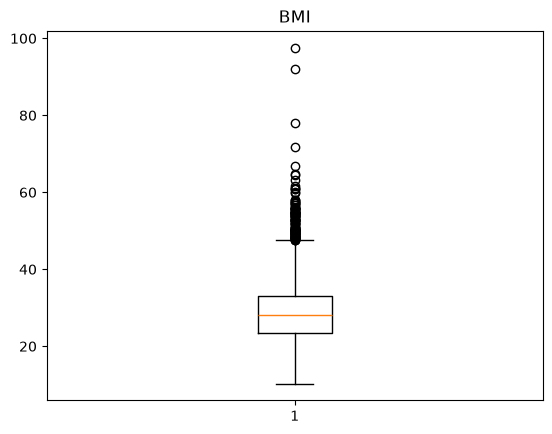

In [6]:
import matplotlib.pyplot as plt

plt.boxplot(df["bmi"].dropna())
plt.title("BMI")
plt.show()

The bmi column contained 201 missing values. Since the boxplot showed several outliers, I imputed the missing values using the median instead of the mean. The median is more robust to extreme values and better preserves the central tendency of the data.

In [7]:
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

In [8]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [28]:
df.duplicated().sum()

np.int64(0)

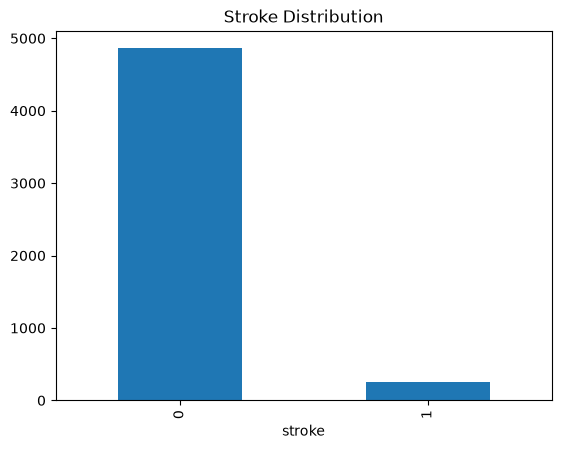

In [29]:
df["stroke"].value_counts().plot(kind="bar")

plt.title("Stroke Distribution")
plt.show()

The dataset is imbalanced because the number of stroke cases is much smaller than non-stroke cases.

In [31]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

<Axes: xlabel='age', ylabel='Count'>

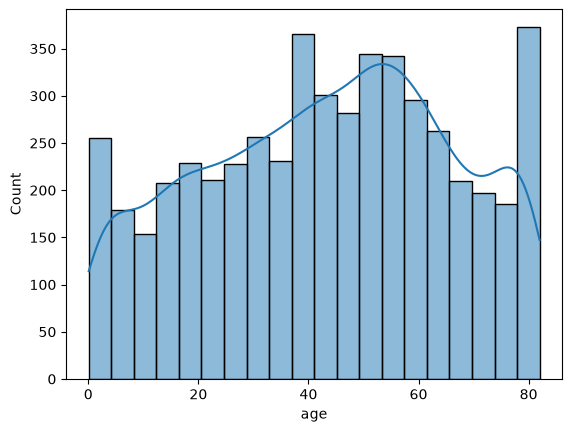

In [32]:
sns.histplot(df["age"], kde=True)

<Axes: xlabel='bmi', ylabel='Count'>

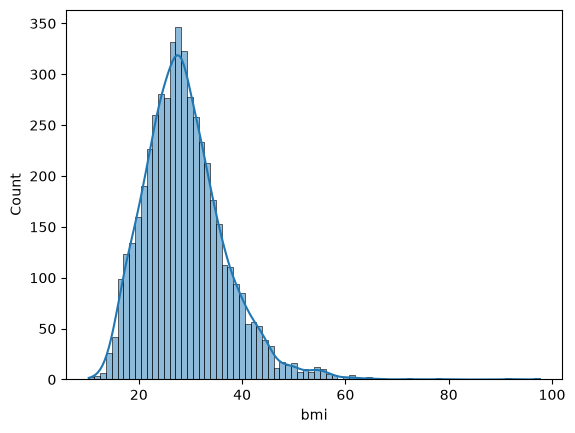

In [33]:
sns.histplot(df["bmi"], kde=True)

<Axes: xlabel='avg_glucose_level', ylabel='Count'>

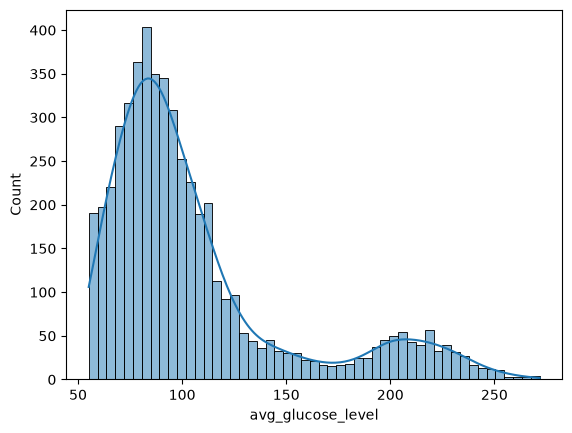

In [34]:
sns.histplot(df["avg_glucose_level"], kde=True)

<Axes: xlabel='gender', ylabel='count'>

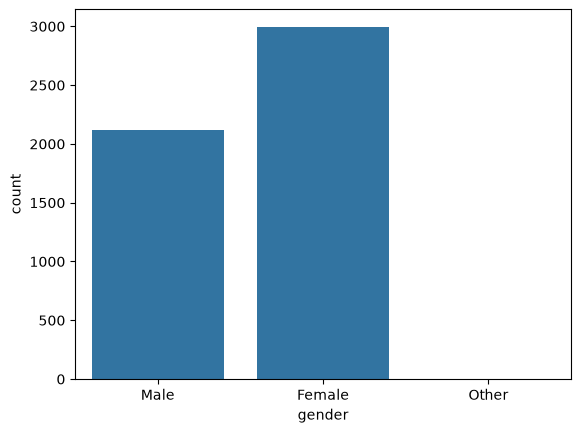

In [35]:
sns.countplot(x="gender", data=df)

<Axes: xlabel='ever_married', ylabel='count'>

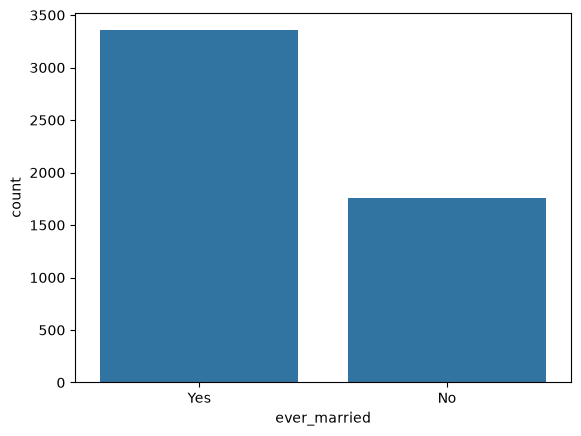

In [36]:
sns.countplot(x="ever_married", data=df)

<Axes: xlabel='smoking_status', ylabel='count'>

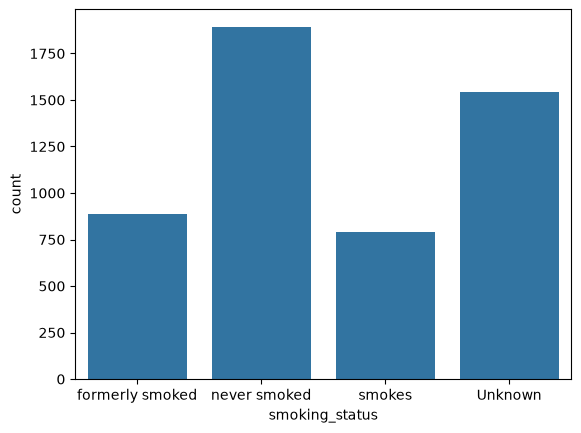

In [37]:
sns.countplot(x="smoking_status", data=df)

<Axes: xlabel='bmi'>

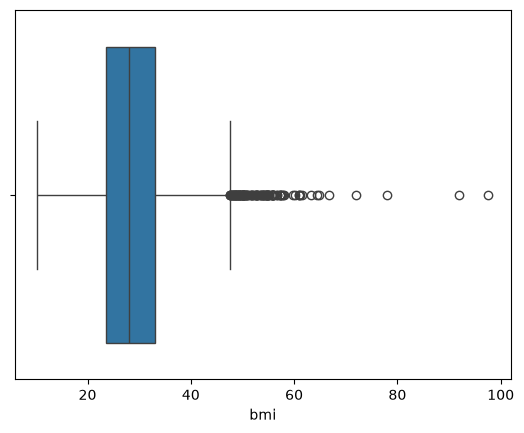

In [41]:
sns.boxplot(x=df["bmi"])

<Axes: xlabel='stroke', ylabel='age'>

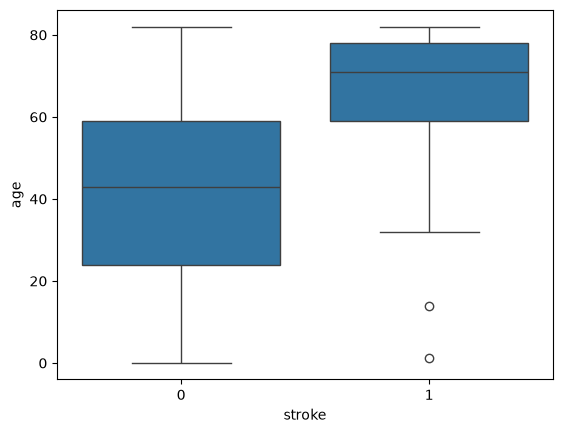

In [38]:
sns.boxplot(
    x="stroke",
    y="age",
    data=df
)

<Axes: xlabel='stroke', ylabel='avg_glucose_level'>

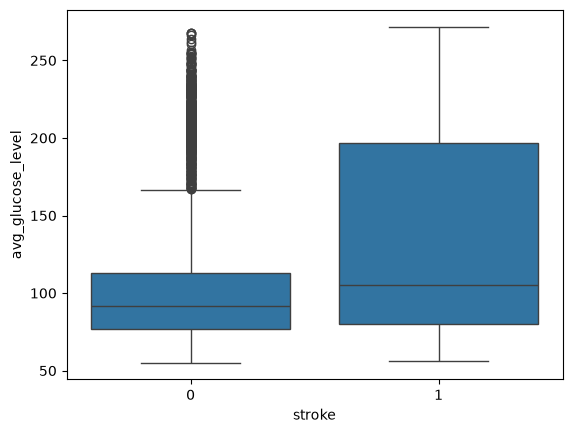

In [39]:
sns.boxplot(
    x="stroke",
    y="avg_glucose_level",
    data=df
)

<Axes: xlabel='hypertension', ylabel='count'>

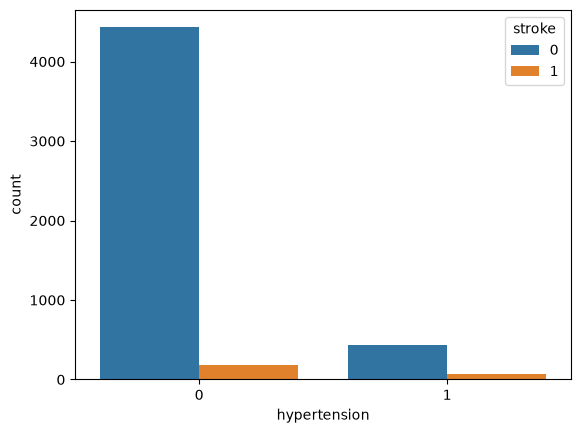

In [40]:
sns.countplot(
    x="hypertension",
    hue="stroke",
    data=df
)

The boxplot shows the presence of outliers in the BMI feature. Since this is a medical dataset, these values may represent real patient conditions (e.g., obesity) rather than data entry errors. Therefore, the outliers were retained and no outlier removal technique was applied.

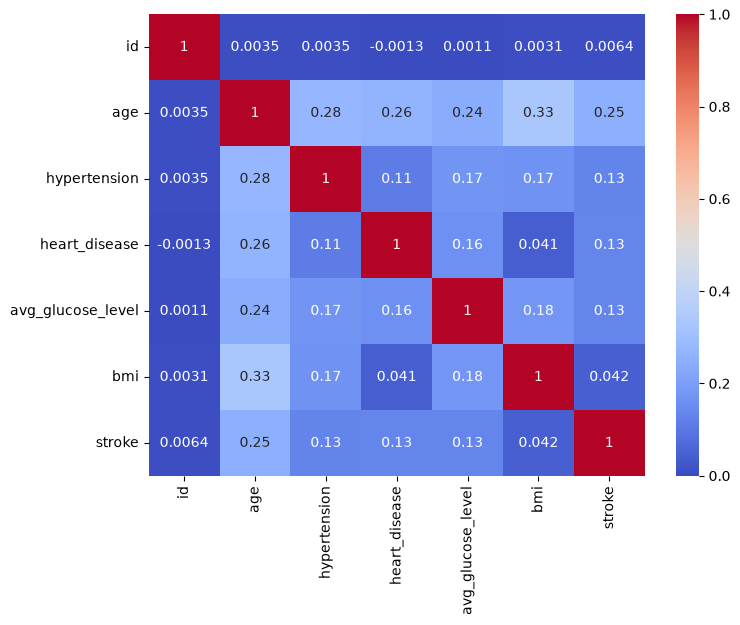

In [30]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

The correlation heatmap shows that age has the strongest positive correlation with stroke (≈0.25), suggesting that older individuals are more likely to experience a stroke. Other features such as hypertension, heart disease, and average glucose level show weak positive correlations, while BMI has a very weak relationship with the target.

In [10]:
df.select_dtypes(include="str").columns

Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='str')

In [17]:
df = df.drop("id", axis=1)

In [18]:
X = df.drop("stroke", axis=1)
y = df["stroke"]

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
categorical_features = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

numerical_features = [
    "age",
    "hypertension",
    "heart_disease",
    "avg_glucose_level",
    "bmi"
]

In [19]:

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [50]:
models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42,
            class_weight="balanced"
        ))
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced"
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
    random_state=42,
    class_weight="balanced_subsample",
    n_estimators=200
))
    ]),

    "SVM": Pipeline([
        ("preprocessor", preprocessor),
        ("model", SVC(
            random_state=42,
            class_weight="balanced"
        ))
    ]),

    "KNN": Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier())
    ])
}

In [67]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results[name] = {
        "y_pred": y_pred,
        "report": classification_report(
            y_test,
            y_pred,
            output_dict=True
        ),
        "cm": confusion_matrix(y_test, y_pred)
    }

In [71]:
baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

baseline_report = classification_report(
    y_test,
    baseline_pred,
    output_dict=True,
    zero_division=0
)

In [72]:
comparison = []

# Add Baseline result
comparison.append({
    "Model": "Baseline (Most Frequent)",
    "Accuracy": baseline_report["accuracy"],
    "Stroke Precision": baseline_report["1"]["precision"],
    "Stroke Recall": baseline_report["1"]["recall"],
    "Stroke F1": baseline_report["1"]["f1-score"]
})


# Add ML models results
for name, result in results.items():

    report = result["report"]

    comparison.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Stroke Precision": report["1"]["precision"],
        "Stroke Recall": report["1"]["recall"],
        "Stroke F1": report["1"]["f1-score"]
    })


comparison_df = pd.DataFrame(comparison)

comparison_df.sort_values(
    by="Stroke Recall",
    ascending=False
)

,Model,Accuracy,Stroke Precision,Stroke Recall,Stroke F1
1,Logistic Regression,0.745597,0.137931,0.80,0.235294
4,SVM,0.755382,0.137681,0.76,0.233129
2,Decision Tree,0.929550,0.156250,0.10,0.121951
5,KNN,0.943249,0.100000,0.02,0.033333
0,Baseline (Most Frequent),0.951076,0.000000,0.00,0.000000
3,Random Forest,0.950098,0.000000,0.00,0.000000


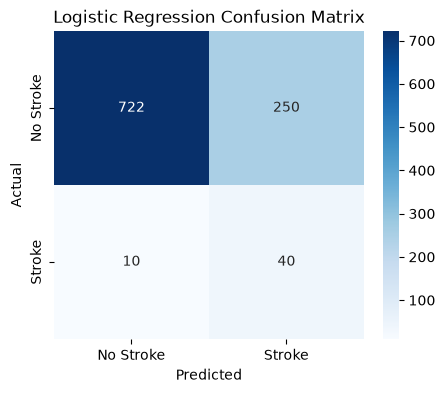

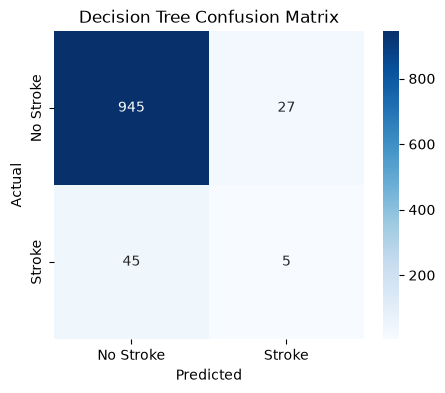

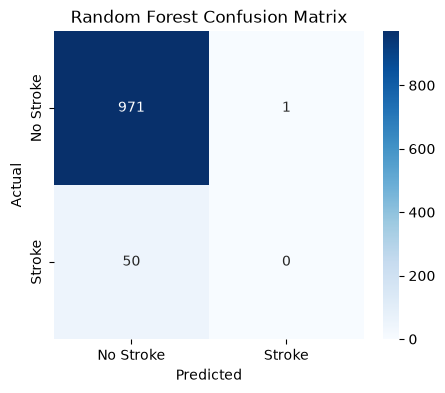

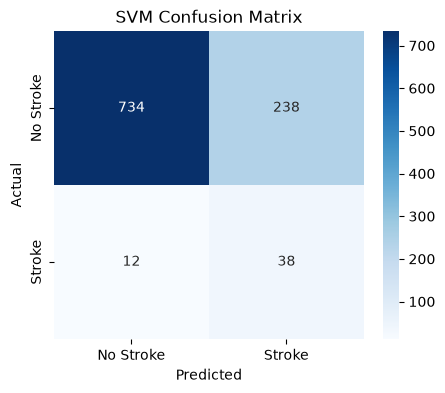

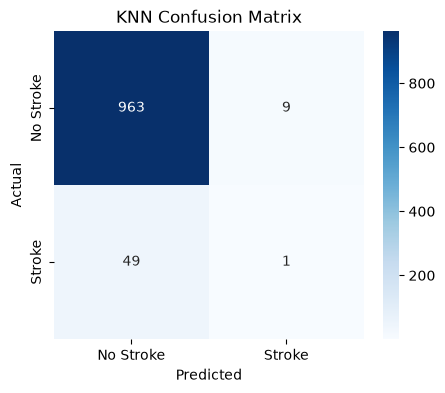

In [73]:
for name, result in results.items():

    plt.figure(figsize=(5,4))

    sns.heatmap(
        result["cm"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Stroke", "Stroke"],
        yticklabels=["No Stroke", "Stroke"]
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

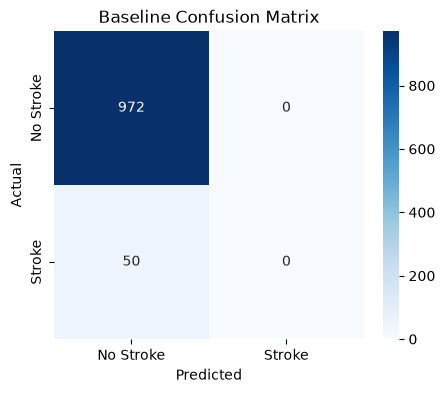

In [74]:
baseline_cm = confusion_matrix(
    y_test,
    baseline_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    baseline_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Stroke", "Stroke"],
    yticklabels=["No Stroke", "Stroke"]
)

plt.title("Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Baseline Comparison

A Dummy Classifier was used as a baseline model to compare the performance of the trained classification models.

The baseline predicts the majority class (`stroke = 0`) for all samples. Although it achieved a high accuracy of 95%, it failed to detect any stroke cases, resulting in a recall of 0% for the stroke class.

This happens because the dataset is highly imbalanced, where non-stroke cases represent the majority of the data.

Compared with the baseline, Logistic Regression achieved a significantly higher recall for stroke cases (80%), showing that it learned useful patterns from the features and was able to identify patients with a higher risk of stroke.

Therefore, accuracy alone is not a suitable metric for this healthcare problem, and recall for the stroke class was considered the main evaluation metric.

## Model Selection and Evaluation

The dataset is highly imbalanced, where the number of non-stroke cases is much higher than stroke cases. Therefore, accuracy alone is not a reliable metric for evaluating model performance.

For this problem, **Stroke Recall** is considered the most important metric because it measures the ability of the model to correctly identify patients who actually have a stroke. Missing a stroke case (False Negative) is more critical than incorrectly predicting stroke for a healthy person.

### Model Comparison

Based on the evaluation results:

- **Logistic Regression** achieved the highest Stroke Recall (**80%**), meaning it successfully detected most of the actual stroke cases.
- **SVM** also performed well with a Stroke Recall of **76%**, making it a strong alternative.
- Although **Random Forest**, **Decision Tree**, and **KNN** achieved higher accuracy values, their Stroke Recall was significantly lower. This means they correctly classified most non-stroke cases but failed to detect many stroke patients.

### Why Logistic Regression Was Selected?

Logistic Regression was selected as the best model because it provided the best performance for the main objective of this healthcare problem: detecting stroke cases.

Using `class_weight="balanced"` helped the model handle the class imbalance by giving more importance to the minority class (`stroke = 1`). As a result, the model became more sensitive to stroke cases and achieved a higher recall.

For example:

- Logistic Regression detected **80%** of stroke cases.
- Random Forest detected only **10%** of stroke cases despite having higher accuracy.

Therefore, Logistic Regression is more suitable for this dataset because it reduces the risk of missing patients who may actually have a stroke.